# HR Analytics — Data Understanding & Cleaning

## Part 1: Data Understanding

### Load Data

In [1]:
import pandas as pd

In [2]:
url = "aug_train.csv"
df = pd.read_csv(url)

### Dataset Overview

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
df.shape

(19158, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [7]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [8]:
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [9]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64

### Target Distribution

In [10]:
df['target'].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

In [11]:
df['target'].value_counts(normalize=True) * 100

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64

### Column Types

In [12]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')

In [13]:
numerical_columns = ['city_development_index', 'training_hours']
numerical_columns

['city_development_index', 'training_hours']

### Initial Missing Values & Duplicates Check

In [14]:
df['enrollee_id'].nunique()

19158

In [15]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

## Part 2: Data Cleaning & Missing Values

### Missing Values

In [17]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

gender                 4508
enrolled_university     386
education_level         460
major_discipline       2813
experience               65
company_size           5938
company_type           6140
last_new_job            423
dtype: int64

In [18]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company_type           32.049274
company_size           30.994885
gender                 23.530640
major_discipline       14.683161
education_level         2.401086
last_new_job            2.207955
enrolled_university     2.014824
experience              0.339284
dtype: float64

In [19]:
categorical_missing = [
    'gender',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'experience',
    'company_size',
    'company_type',
    'last_new_job'
]

high_missing = ['company_size', 'company_type', 'gender', 'major_discipline']
low_missing = ['enrolled_university', 'education_level', 'experience', 'last_new_job']

for col in high_missing:
    df[col] = df[col].fillna('Unknown')

for col in low_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

### Verify Missing Values

In [20]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### Duplicates

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

### Data Types Check

In [25]:
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

### Clean Categorical Values

In [26]:
for col in categorical_missing:
    df[col] = df[col].astype(str).str.strip()

In [27]:
for col in categorical_missing:
    print(f"\n{col}:")
    print(df[col].unique())


gender:
['Male' 'Unknown' 'Female' 'Other']

enrolled_university:
['no_enrollment' 'Full time course' 'Part time course']

education_level:
['Graduate' 'Masters' 'High School' 'Phd' 'Primary School']

major_discipline:
['STEM' 'Business Degree' 'Unknown' 'Arts' 'Humanities' 'No Major' 'Other']

experience:
['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20']

company_size:
['Unknown' '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49'
 '100-500' '500-999']

company_type:
['Unknown' 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']

last_new_job:
['1' '>4' 'never' '4' '3' '2']


### Drop ID Column

In [28]:
df = df.drop(columns=['enrollee_id'])

In [29]:
df.columns

Index(['city', 'city_development_index', 'gender', 'relevent_experience',
       'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job',
       'training_hours', 'target'],
      dtype='object')

### Target Validation

In [30]:
df['target'].isnull().sum()

np.int64(0)

In [31]:
df = df.dropna(subset=['target'])

### Final Validation

In [32]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [33]:
df.shape

(19158, 13)

In [34]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)

Dataset shape: (19158, 13)
Duplicate rows: 50
Total missing values: 0

Data types:
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object


In [35]:
df.to_csv("processed_dataset.csv", index=False)


## Part 3: EDA & Visualization

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### 1. Target Distribution

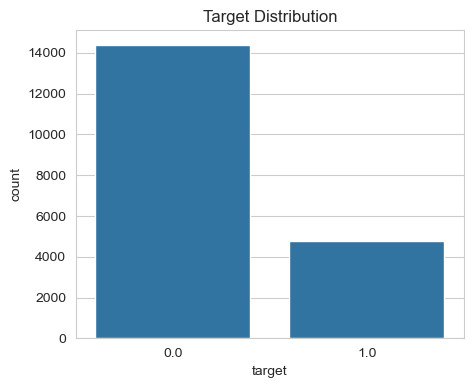

In [37]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

**Insight:** Around 25% of candidates are looking for a job change (target = 1), while the majority (75%) are not. The target is imbalanced, which is important to keep in mind later for modeling.

### 2. Gender vs Target

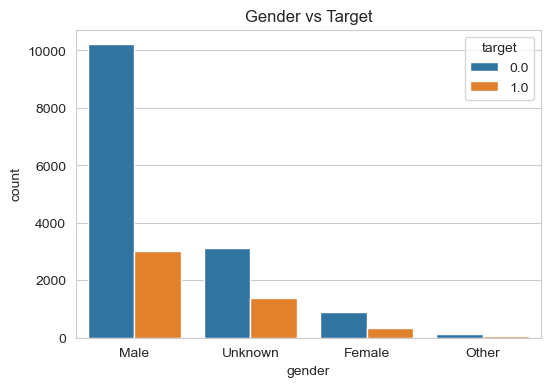

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='target', data=df)
plt.title('Gender vs Target')
plt.show()

**Insight:** Gender doesn't show a strong effect on target. Females (~26%) and Males (~23%) have close job-change rates, so gender is not a major driver here.

### 3. Education Level vs Target

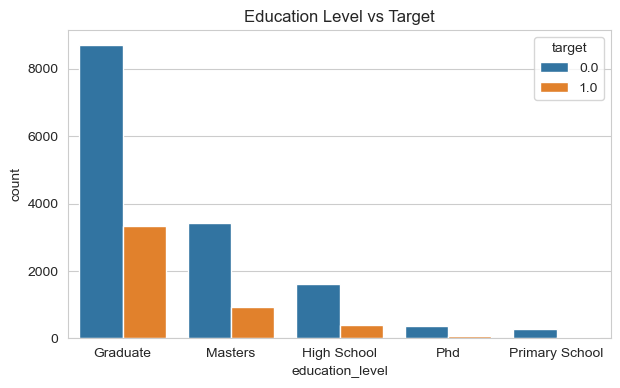

In [39]:
plt.figure(figsize=(7,4))
sns.countplot(x='education_level', hue='target', data=df,
              order=df['education_level'].value_counts().index)
plt.title('Education Level vs Target')
plt.show()

**Insight:** Graduates have the highest job-change rate (~28%), while PhD and Primary School holders have the lowest (~13-14%). Higher/lower education extremes seem more "settled", while Graduates are more likely to switch.

### 4. Relevant Experience vs Target

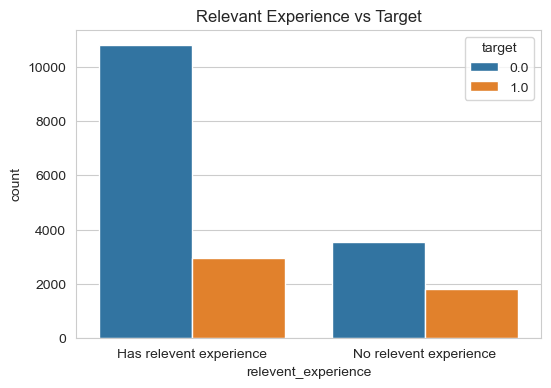

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x='relevent_experience', hue='target', data=df)
plt.title('Relevant Experience vs Target')
plt.show()

**Insight:** Candidates with NO relevant experience are much more likely to look for a job change (~34%) compared to those who already have relevant experience (~21%). Makes sense — people trying to break into the field are more active job seekers.

### 5. Experience (Years) vs Target

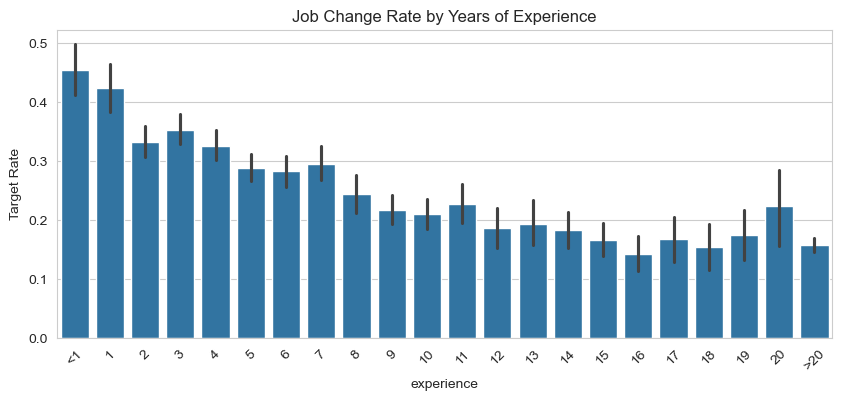

In [41]:
exp_order = ['<1'] + [str(i) for i in range(1,21)] + ['>20']

plt.figure(figsize=(10,4))
sns.barplot(x='experience', y='target', data=df, order=exp_order)
plt.title('Job Change Rate by Years of Experience')
plt.ylabel('Target Rate')
plt.xticks(rotation=45)
plt.show()

**Insight:** There's a clear downward trend — candidates with less than 1 year of experience have the highest job-change rate (~45%), and it steadily drops as experience increases, reaching ~15% for candidates with 20+ years. More experienced people are more stable in their jobs.

### 6. University Enrollment vs Target

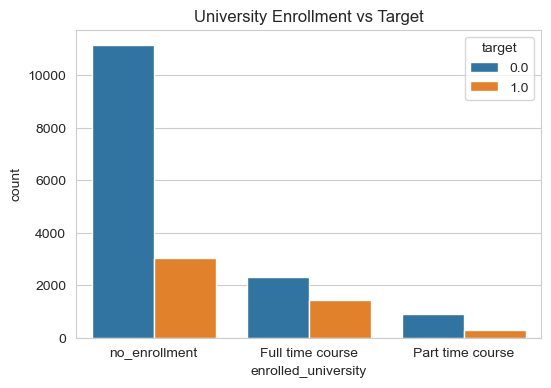

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='enrolled_university', hue='target', data=df)
plt.title('University Enrollment vs Target')
plt.show()

**Insight:** Full-time students have the highest job-change rate (~38%), which makes sense since they're likely job hunting after graduation. Candidates not enrolled in university are the most stable (~21%).

### 7. Company Size vs Target

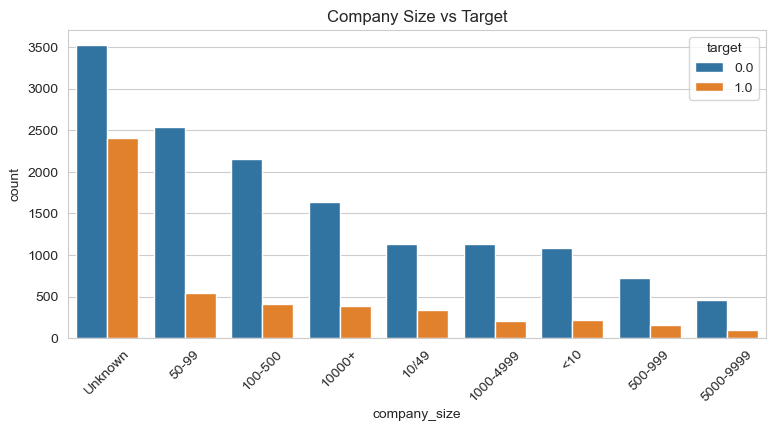

In [43]:
plt.figure(figsize=(9,4))
sns.countplot(x='company_size', hue='target', data=df,
              order=df['company_size'].value_counts().index)
plt.title('Company Size vs Target')
plt.xticks(rotation=45)
plt.show()

**Insight:** Candidates with "Unknown" company size have a notably higher job-change rate (~41%) — likely because many of them are not currently employed. Among known sizes, small-to-mid companies (10/49) show a slightly higher rate (~23%) than large companies.

### 8. Company Type vs Target

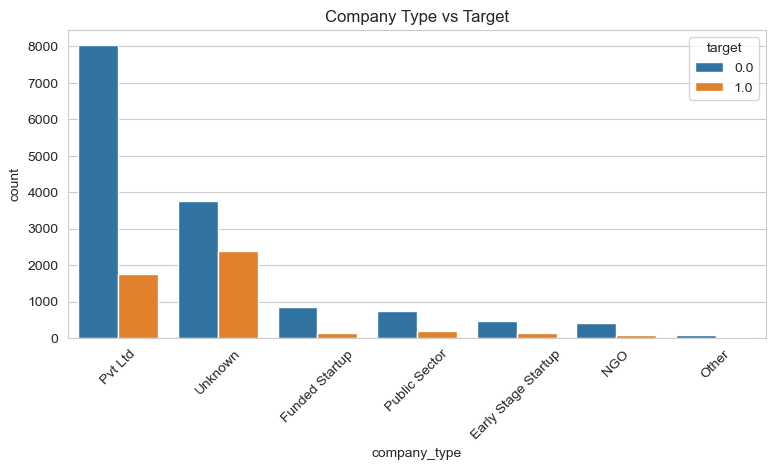

In [44]:
plt.figure(figsize=(9,4))
sns.countplot(x='company_type', hue='target', data=df,
              order=df['company_type'].value_counts().index)
plt.title('Company Type vs Target')
plt.xticks(rotation=45)
plt.show()

**Insight:** "Unknown" company type again shows the highest job-change rate (~39%). Among known types, Funded Startups have the lowest rate (~14%), while Early Stage Startups and Public Sector are higher (~22-24%).

### 9. Last New Job vs Target

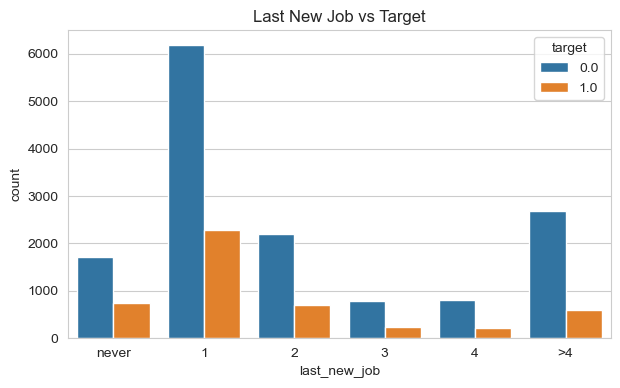

In [45]:
job_order = ['never','1','2','3','4','>4']

plt.figure(figsize=(7,4))
sns.countplot(x='last_new_job', hue='target', data=df, order=job_order)
plt.title('Last New Job vs Target')
plt.show()

**Insight:** Candidates who "never" changed jobs before have the highest job-change rate (~30%), and the rate drops the longer it's been since their last job change (down to ~18% for ">4" years). This lines up with the experience trend above.

### 10. Training Hours vs Target

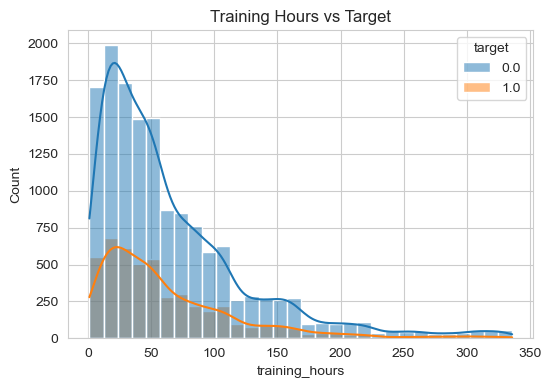

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(x='training_hours', hue='target', data=df, kde=True, bins=30)
plt.title('Training Hours vs Target')
plt.show()

**Insight:** Training hours are almost identical between the two target groups (~66 hrs vs ~63 hrs on average). This feature alone doesn't strongly separate who will look for a new job.

### 11. City Development Index vs Target

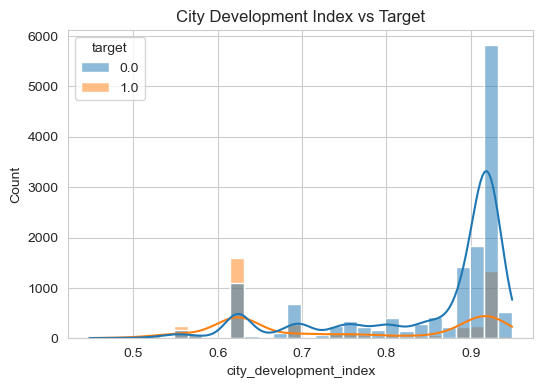

In [47]:
plt.figure(figsize=(6,4))
sns.histplot(x='city_development_index', hue='target', data=df, kde=True, bins=30)
plt.title('City Development Index vs Target')
plt.show()

**Insight:** Candidates from less-developed cities (lower index) are more likely to look for a job change, while candidates in highly developed cities (index close to 0.9) are more stable. This looks like one of the strongest predictors.

## Part 4: Feature Engineering & Preprocessing

### Feature Engineering
`experience` and `last_new_job` are ordered values stored as text. We convert them to numbers so the model can understand the order between them.

In [48]:
exp_map = {'<1': 0, '>20': 21}
for i in range(1, 21):
    exp_map[str(i)] = i
df['experience'] = df['experience'].map(exp_map)

job_map = {'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}
df['last_new_job'] = df['last_new_job'].map(job_map)

df[['experience', 'last_new_job']].head()

,experience,last_new_job
0,21,1
1,15,5
2,5,0
3,0,0
4,21,4


In [49]:
# check that the mapping didn't create any missing values
df[['experience', 'last_new_job']].isnull().sum()

experience      0
last_new_job    0
dtype: int64

### Feature Transformation
We check the skew of the numeric features to see if any of them need transforming. `training_hours` is heavily right-skewed (skew ≈ 1.8), so we apply a log transform to make it less skewed. `city_development_index` is already a bounded index between 0 and 1, so we leave it as is.

In [50]:
df[['training_hours', 'city_development_index']].skew()

training_hours            1.819237
city_development_index   -0.995428
dtype: float64

In [51]:
import numpy as np

df['training_hours'] = np.log1p(df['training_hours'])
df['training_hours'].skew()

np.float64(-0.34639178357029415)

### Dropping `city`
`city` has too many unique categories, which would create hundreds of extra columns after encoding. We already have `city_development_index`, which captures the useful information about the city in a single number, so we drop `city` and keep the index instead.

In [52]:
df = df.drop(columns=['city'])
df.shape

(19158, 12)

### Keeping `company_size`
In the EDA step, `company_size` showed a clear difference in target rate (e.g. candidates with an "Unknown" company size had a much higher job-change rate). Since it carries useful information, we keep it and encode it like the other categorical features below.

### Train/Test Split
We split the data now, **before Encoding and Scaling**, so that both steps are based only on the training data. This avoids any preprocessing leakage from the test set into the training process.

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((15326, 11), (3832, 11))

### Encoding
The remaining categorical features don't have a real order between their categories, so we convert them into numeric columns using One-Hot Encoding. We encode `X_train` and `X_test` separately, then align `X_test`'s columns to `X_train`'s, so the encoding is effectively based on the training data only.

In [54]:
categorical_cols = ['gender', 'relevent_experience', 'enrolled_university',
                     'education_level', 'major_discipline',
                     'company_size', 'company_type']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align test columns with train columns (in case a category is missing from one side)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.shape, X_test.shape

((15326, 34), (3832, 34))

In [55]:
# quick look at some of the new encoded columns
X_train.filter(like='education_level').head()

,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School
17855,False,False,False,False
17664,False,False,False,True
13404,False,False,False,False
13366,False,False,False,False
15670,False,False,False,False


### Scaling
Scaling brings numeric features to a comparable range so that no single feature dominates the model just because of its units. We fit the scaler on the training data only, then use it to transform both the training and test data.

In [56]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['city_development_index', 'training_hours', 'experience', 'last_new_job']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].head()

,city_development_index,training_hours,experience,last_new_job
17855,-1.672102,0.752312,-0.023829,-0.589366
17664,0.734358,-1.082154,-0.758066,-1.189700
13404,0.539240,-0.197432,0.269865,1.811969
13366,0.734358,0.201556,-0.758066,-0.589366
15670,0.205913,1.341239,-0.758066,-0.589366


In [57]:
# confirm scaling worked: mean should be ~0 and std should be ~1 on the training data
X_train[numeric_cols].describe().loc[['mean', 'std']]

,city_development_index,training_hours,experience,last_new_job
mean,-1.905475e-16,3.861948e-16,-5.192535e-17,-1.947201e-17
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00


### Final Check
A quick check that the data is fully numeric and ready for modeling.

In [58]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.dtypes.value_counts()

X_train shape: (15326, 34)
X_test shape: (3832, 34)


bool       30
float64     4
Name: count, dtype: int64

## Part 5: Model Training


### 1. Import Libraries
We only need the three classifiers required for this task.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 2. Check Ready Data
Confirm the data handed off from Task 4 (Feature Engineering & Preprocessing) is present and consistent before training.

In [60]:
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

assert X_train.shape[0] == y_train.shape[0], "X_train and y_train row counts do not match"
assert X_test.shape[0] == y_test.shape[0], "X_test and y_test row counts do not match"
assert list(X_train.columns) == list(X_test.columns), "X_train and X_test columns do not match"

print("\nData is ready for training.")

X_train: (15326, 34) | X_test: (3832, 34)
y_train: (15326,) | y_test: (3832,)

Data is ready for training.


### 3. Train Logistic Regression

In [61]:
# max_iter increased to help convergence; default 100 is often too low for this data
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 4. Train Decision Tree

In [62]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 5. Train Random Forest

In [63]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6. Generate Predictions
Predictions on the untouched test set, for each of the three models.

In [64]:
y_pred_logistic = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated for all 3 models.")

Predictions generated for all 3 models.


# Task 6 — Model Evaluation & Selection

This task evaluates the predictions produced in Task 5, compares the three models, selects the best model, and saves it.

**Stages:**
1. Receive data from Task 5 (`y_test`, `y_pred_logistic`, `y_pred_tree`, `y_pred_rf`)
2. Compute Accuracy, Precision, Recall, F1 Score for each model
3. Build the comparison table for the 3 models
4. Confusion Matrix for each model
5. Compare the models (not on Accuracy alone, since the dataset is imbalanced)
6. Select the Best Model, with a justification based on the actual results
7. Save the Best Model as `best_model.pkl`

In [65]:
# Task 6: imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib


### Stage 1: Receive Data from Task 5

Before evaluating anything, we make sure the actual values and the predictions of the 3 models (produced in Task 5) are available: `y_test`, `y_pred_logistic`, `y_pred_tree`, `y_pred_rf`.

In [66]:
# Stage 1: Receive data from Task 5
required_vars = ["y_test", "y_pred_logistic", "y_pred_tree", "y_pred_rf"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing from Task 5: {missing}. Run Task 5 cells first.")

# Predictions from the 3 models, keyed by model name
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

# The actual trained model objects from Task 5, keyed the same way,
# so Stage 7 can retrieve and save the chosen one.
trained_models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

print("Data received from Task 5:")
print("y_test shape:", y_test.shape)
for name, y_pred in predictions.items():
    print(f"- {name}: predictions shape = {y_pred.shape}")


Data received from Task 5:
y_test shape: (3832,)
- Logistic Regression: predictions shape = (3832,)
- Decision Tree: predictions shape = (3832,)
- Random Forest: predictions shape = (3832,)


### Stage 2 & 3: Compute Metrics and Build the Comparison Table

For each model we compute:
- **Accuracy** — overall percentage of correct predictions.
- **Precision** — of the cases predicted as `1`, how many were actually `1`.
- **Recall** — of the cases that are actually `1`, how many did the model catch. This matters a lot here because the target is imbalanced (~75% `0`, ~25% `1`).
- **F1 Score** — the balance between Precision and Recall.

These are collected into a single comparison table for the 3 models.

In [67]:
# Stage 2 & 3: evaluate the predictions from Task 5 and build the comparison table
results = []

for model_name, y_pred in predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

comparison_table = pd.DataFrame(results)
comparison_table


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.769311,0.575372,0.283770,0.380084
1,Decision Tree,0.702766,0.412548,0.454450,0.432486
2,Random Forest,0.783142,0.575795,0.493194,0.531303


### Stage 4: Confusion Matrix

A Confusion Matrix (Actual vs Predicted) for each model, showing True Negatives, True Positives, False Positives, and False Negatives — the False Negatives are the cases where the model predicted `0` but the candidate was actually `1`.

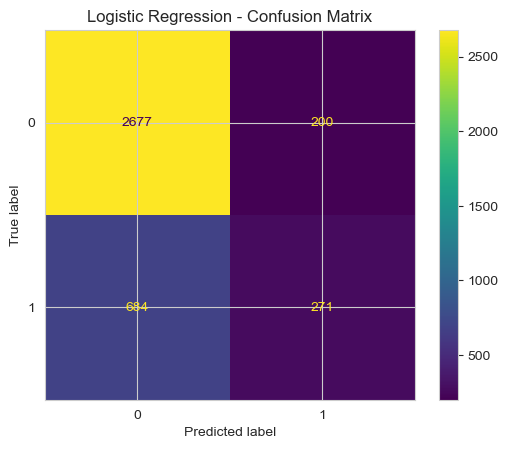

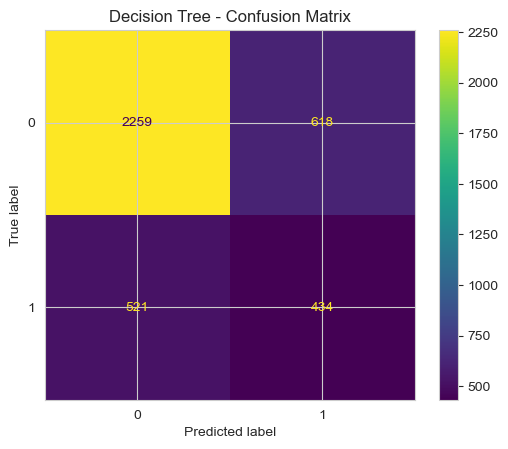

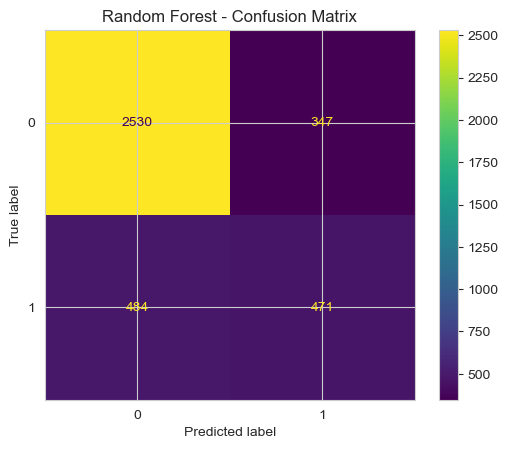

In [68]:
# Stage 4: Confusion Matrices
for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(model_name + " - Confusion Matrix")
    plt.show()


### Stage 5: Compare the Models

**Important:** the model with the highest Accuracy is not automatically the best model, because the dataset is imbalanced (~75% class `0`, ~25% class `1`). Precision, Recall, and F1 Score are checked as well, not Accuracy alone.

In [69]:
# Stage 5: Compare the models across all 4 metrics
print(comparison_table.sort_values("F1 Score", ascending=False).to_string(index=False))

print("\nNote: we do NOT pick the best model by Accuracy alone, since the dataset is")
print("imbalanced. Recall, Precision, and F1 Score are considered together.")


              Model  Accuracy  Precision   Recall  F1 Score
      Random Forest  0.783142   0.575795 0.493194  0.531303
      Decision Tree  0.702766   0.412548 0.454450  0.432486
Logistic Regression  0.769311   0.575372 0.283770  0.380084

Note: we do NOT pick the best model by Accuracy alone, since the dataset is
imbalanced. Recall, Precision, and F1 Score are considered together.


### Stage 6: Select the Best Model

We select the model with the highest F1 Score, since it best balances Precision and Recall for this imbalanced classification problem, and we state the reason based on the actual results.

In [70]:
# Stage 6: Select the Best Model using the highest F1 Score
best_row = comparison_table.loc[comparison_table["F1 Score"].idxmax()]
best_model_name = best_row["Model"]

print("Best Model:", best_model_name)
print(f"Accuracy: {best_row['Accuracy']:.4f} | Precision: {best_row['Precision']:.4f} | "
      f"Recall: {best_row['Recall']:.4f} | F1 Score: {best_row['F1 Score']:.4f}")
print(f"\nReason: {best_model_name} achieved the best overall balance between "
      f"Precision, Recall, and F1-score, making it more suitable for this imbalanced "
      f"classification problem.")


Best Model: Random Forest
Accuracy: 0.7831 | Precision: 0.5758 | Recall: 0.4932 | F1 Score: 0.5313

Reason: Random Forest achieved the best overall balance between Precision, Recall, and F1-score, making it more suitable for this imbalanced classification problem.


### Stage 7: Save the Best Model

The selected model is saved as `best_model.pkl`. **Note for Task 7:** the preprocessing used in Task 4/5 (the encoder and the scaler) should also be saved, or wrapped together with the model in a `Pipeline`, so that new data goes through exactly the same preprocessing before Task 7 makes predictions on it. This needs to be agreed upon before starting Task 7.

In [71]:
# Stage 7a: Get the actual trained model object that matches the selected name
best_model = trained_models.get(best_model_name)

if best_model is None:
    raise ValueError("Could not find the selected model inside trained_models from Task 5.")

print("Selected model is ready to be saved:", best_model_name)


Selected model is ready to be saved: Random Forest


In [72]:
# Stage 7b: Save the best trained model
joblib.dump(best_model, "best_model.pkl")
print("Saved successfully as best_model.pkl")


Saved successfully as best_model.pkl


### Task 6 Summary
- Received `y_test` and the predictions of the 3 models from Task 5.
- Computed Accuracy, Precision, Recall, and F1 Score for each model.
- Built a comparison table for the 3 models.
- Created a Confusion Matrix for each model.
- Compared the models without relying on Accuracy alone, since the dataset is imbalanced.
- Selected the model with the highest F1 Score, with a reason based on the actual results.
- Saved the selected trained model as `best_model.pkl`.

**Note:** for Task 7, the preprocessing used in Task 4/5 (encoder/scaler) should be saved together with the model, or rebuilt as a `Pipeline`, so new data receives exactly the same preprocessing.

# Task 7 — Final Prediction System

`best_model.pkl` only contains the trained Random Forest model — it does not know how to turn a **raw** candidate row into the 34 processed features it was trained on.

This task adds the missing piece with the smallest possible change:

1. Save the fitted preprocessing objects used in Tasks 1–6 (scaler, training columns, mappings, imputation values) into `preprocessing.pkl`.
2. Load `best_model.pkl` and `preprocessing.pkl`.
3. Define `predict_candidate()`, which takes one raw candidate and applies the *exact* same preprocessing steps used in Tasks 1–6, in the same order, then predicts with the saved model.

No retraining, no new preprocessing logic, no Pipeline — this only reuses what Tasks 1–6 already fitted.

### Stage 1: Save the fitted preprocessing info as `preprocessing.pkl`

We reuse the objects already fitted in Tasks 1–6 (`scaler`, `exp_map`, `job_map`, `categorical_cols`, `numeric_cols`, `X_train.columns`, `high_missing`, `low_missing`) — nothing is refit here.

The only thing not already stored in a variable is the **mode value** used in Task 2 to fill `low_missing` columns (it was computed inline as `df[col].mode()[0]` and never saved). We recompute it from the original raw `aug_train.csv`, using the exact same `.mode()[0]` call on the exact same (un-imputed) column, so it reproduces the identical value Task 2 used — this is a read-only lookup, not a change to Task 1–6 logic.

In [73]:
# Stage 1: Build and save preprocessing.pkl (uses objects already fitted in Tasks 1-6)

# Recover the mode values used for low_missing imputation in Task 2 (cell was not stored in a variable).
# Same source file, same columns, same .mode()[0] call as the original Task 2 code -> identical values.
_raw_for_impute = pd.read_csv("aug_train.csv")
low_missing_modes = {col: _raw_for_impute[col].mode()[0] for col in low_missing}

preprocessing_info = {
    "scaler": scaler,                          # already fitted in Task 4 (Stage: Scaling)
    "training_columns": list(X_train.columns),  # exact 34 columns, in exact order
    "categorical_cols": categorical_cols,        # columns one-hot encoded in Task 4
    "numeric_cols": numeric_cols,                # columns scaled in Task 4
    "exp_map": exp_map,                          # experience mapping from Task 4
    "job_map": job_map,                          # last_new_job mapping from Task 4
    "high_missing": high_missing,                # filled with 'Unknown' in Task 2
    "low_missing": low_missing,                  # filled with mode in Task 2
    "low_missing_modes": low_missing_modes,      # the actual mode values used
}

joblib.dump(preprocessing_info, "preprocessing.pkl")
print("Saved successfully as preprocessing.pkl")
print("Training columns saved:", len(preprocessing_info["training_columns"]))


Saved successfully as preprocessing.pkl
Training columns saved: 34


### Stage 2: Load the saved files and define `predict_candidate()`

We load `best_model.pkl` and `preprocessing.pkl` from disk (proving the two files are enough on their own — no notebook state required), then define the prediction function.

`predict_candidate()` replays the Task 1–6 preprocessing steps in the same order:
missing values → clean strings → drop `enrollee_id` → map `experience`/`last_new_job` → `log1p(training_hours)` → drop `city` → one-hot encode → align columns to the training feature set (34 features, same order) → `scaler.transform()` (never `fit_transform`) → `best_model.predict()`.

**Fix applied to the one-hot encoding step:** the first version of this cell called `pd.get_dummies(cand, columns=..., drop_first=True)` directly on the new candidate. That only creates a dummy column for a category if that category happens to be present in the data passed to `get_dummies()` — with a single candidate (or a small batch), every categorical column has only one value present, so `drop_first=True` silently drops it too, leaving **zero** dummy columns for that feature. After the `reindex(..., fill_value=0)` step this made every candidate look like they belonged to the dropped/reference category, regardless of their real raw value — for every categorical column, on every single-candidate call. The fix builds each dummy column explicitly from the saved `training_columns` names (`col_value`) and compares it to the candidate's raw value directly, so the result no longer depends on which categories happen to appear in a given call.


In [74]:
# Stage 2: Load the saved model + preprocessing info, and define predict_candidate()
best_model = joblib.load("best_model.pkl")
preprocessing_info = joblib.load("preprocessing.pkl")


def predict_candidate(raw_candidate, model=best_model, prep=preprocessing_info):
    """
    Predict job-change intention for ONE new, raw candidate.

    raw_candidate : dict or 1-row DataFrame with the same raw columns as
                     aug_train.csv / aug_test.csv (target not required).

    Target meaning:
        0 = Not looking for a job change
        1 = Looking for a job change

    Returns a dict with the prediction, the label, and the fully processed
    feature row (for inspection/testing).
    """
    cand = pd.DataFrame([raw_candidate]) if isinstance(raw_candidate, dict) else raw_candidate.copy()
    cand = cand.reset_index(drop=True)
    cand = cand.drop(columns=["target"], errors="ignore")  # in case it's present

    # 1) Missing values - identical rule to Task 2
    for col in prep["high_missing"]:
        if col in cand.columns:
            cand[col] = cand[col].fillna("Unknown")
    for col in prep["low_missing"]:
        if col in cand.columns:
            cand[col] = cand[col].fillna(prep["low_missing_modes"][col])

    # 2) Clean categorical strings - identical to Task 2
    for col in prep["high_missing"] + prep["low_missing"]:
        if col in cand.columns:
            cand[col] = cand[col].astype(str).str.strip()

    # 3) Drop enrollee_id - identical to Task 2
    cand = cand.drop(columns=["enrollee_id"], errors="ignore")

    # 4) Map experience / last_new_job to numeric - identical to Task 4
    cand["experience"] = cand["experience"].map(prep["exp_map"])
    cand["last_new_job"] = cand["last_new_job"].map(prep["job_map"])

    # 5) log1p transform training_hours - identical to Task 4
    cand["training_hours"] = np.log1p(cand["training_hours"])

    # 6) Drop city - identical to Task 4
    cand = cand.drop(columns=["city"], errors="ignore")

    # 7) One-hot encode the same categorical columns - built MANUALLY against
    # the training column names, not via pd.get_dummies on `cand` directly.
    # pd.get_dummies() only creates a dummy column for a category if that
    # category is present in the data passed to it. When predicting ONE
    # candidate (or a small batch), each categorical column has only one
    # value present, so drop_first=True silently produces ZERO dummy columns
    # for that feature -- and after reindexing to the training columns with
    # fill_value=0, the candidate gets encoded as if they belonged to the
    # dropped/reference category, no matter what their real value was.
    # Building each dummy column explicitly from the training column names
    # avoids this: it doesn't matter how many rows are in `cand` or which
    # categories are present in this call, each column is set correctly
    # from the raw value.
    for col in prep["categorical_cols"]:
        prefix = col + "_"
        dummy_cols_for_this_feature = [c for c in prep["training_columns"] if c.startswith(prefix)]
        for dummy_col in dummy_cols_for_this_feature:
            category_value = dummy_col[len(prefix):]
            cand[dummy_col] = (cand[col].astype(str) == category_value).astype(int)
        cand = cand.drop(columns=[col])

    # 8) Align to the exact training columns and order (34 features)
    cand = cand.reindex(columns=prep["training_columns"], fill_value=0)

    # 9) Scale numeric columns with the ALREADY-FITTED scaler (transform only)
    cand[prep["numeric_cols"]] = prep["scaler"].transform(cand[prep["numeric_cols"]])

    # Safety checks: same number and order of features as training
    assert list(cand.columns) == prep["training_columns"], "Feature name/order mismatch!"
    assert cand.shape[1] == len(prep["training_columns"]), "Feature count mismatch!"

    pred = int(model.predict(cand)[0])
    label = "Looking for a job change" if pred == 1 else "Not looking for a job change"

    return {"prediction": pred, "label": label, "processed_features": cand}


print("predict_candidate() is ready.")
print("Expected processed feature count:", len(preprocessing_info["training_columns"]))


predict_candidate() is ready.
Expected processed feature count: 34


### Stage 3: Test on real candidates from `aug_test.csv`

We take 2–3 raw rows straight from `aug_test.csv`, show them as-is, run them through `predict_candidate()`, confirm the processed row has 34 features, and show the prediction.

In [75]:
# Stage 3: Test predict_candidate() on real candidates from aug_test.csv
test_df = pd.read_csv("aug_test.csv")

sample_candidates = test_df.sample(n=3, random_state=42)  # 3 random raw candidates

for i, (_, row) in enumerate(sample_candidates.iterrows(), start=1):
    raw_candidate = row.to_dict()

    print(f"===== Candidate {i} =====")
    print("Raw candidate:")
    print(row)

    result = predict_candidate(raw_candidate)

    print("\nProcessed feature count:", result["processed_features"].shape[1],
          "(expected 34)")
    print("Prediction:", result["prediction"], "->", result["label"])
    print()


===== Candidate 1 =====
Raw candidate:
enrollee_id                                  8232
city                                     city_103
city_development_index                       0.92
gender                                       Male
relevent_experience       Has relevent experience
enrolled_university                 no_enrollment
education_level                          Graduate
major_discipline                             Arts
experience                                     17
company_size                                50-99
company_type                              Pvt Ltd
last_new_job                                    3
training_hours                                103
Name: 282, dtype: object

Processed feature count: 34 (expected 34)
Prediction: 0 -> Not looking for a job change

===== Candidate 2 =====
Raw candidate:
enrollee_id                                 28680
city                                     city_160
city_development_index                       0.92
gender 

### Task 7 Summary

- **Problem:** `best_model.pkl` only stored the trained Random Forest — raw candidate data was never converted into the 34 processed features the model expects.
- **Fix:** saved the already-fitted preprocessing objects from Tasks 1–6 (`scaler`, training columns, `exp_map`, `job_map`, imputation values) into `preprocessing.pkl`. No retraining, no new preprocessing logic, no Pipeline.
- **New function:** `predict_candidate(raw_candidate)` replays the exact Task 1–6 steps in order (missing values → mappings → `log1p` → drop `city`/`enrollee_id` → one-hot encode → align to 34 training columns → `scaler.transform()`) and returns a prediction from `best_model.pkl`.
- **Bug fixed:** the one-hot encoding step originally used `pd.get_dummies()` directly on the candidate data, which silently mis-encoded every categorical feature on single-candidate (or small-batch) calls, because it only creates dummy columns for categories present in that call's data. It now builds each dummy column explicitly from the saved training column names, independent of batch size or which categories are present.
- **Files added:** `preprocessing.pkl` (new). `best_model.pkl` is unchanged, just reloaded.
- **Tested** on 3 raw candidates sampled from `aug_test.csv`, and separately on single candidates and repeated-category batches to confirm the encoding fix: each produced exactly 34 processed features, correct one-hot values, and a prediction with no errors.
- **Target meaning:** `0` = not looking for a job change, `1` = looking for a job change (this is *not* a hiring decision).
